# Ocean Heat Content: CESM3 / MOM6 experiment comparison

Extends the global-mean ocean potential temperature/salinity timeseries from
`key_diagnostics.ipynb` (Section 1-2, `thetaoga`/`soga`) with a **depth
breakdown**: volume-averaged temperature and salinity over five depth
ranges (surface, 0-300 m, 300-700 m, 700-2000 m, > 2000 m), each compared
against a WOA-2018 reference. The shared `Experiment` class lives in
`experiment.py` so it can be reused across notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Method** (`Experiment.compute_ocean_heat_content`): reads `thetao`, `so`
and the precomputed cell-volume diagnostic `volcello` from the full
z-coordinate history (`*.mom6.h.z.*`, the full simulation, matching
`thetaoga`'s time range, not just the standard 31-54 averaging window).
`volcello` is the model's own grid-cell volume (already correctly handling
partial bottom cells), so no `h * area` reconstruction is needed.

Rather than reducing separately per depth range, the horizontal (`xh`,
`yh`) integral of `var * volcello` and of `volcello` alone is computed
*once* for the full vertical profile, giving two small `(time, z_l)`
arrays (`thetao_volcello_profile`/`so_volcello_profile` and
`volcello_profile`, all cached alongside the derived depth ranges). Every
requested depth-range average -- including `surface`, which is just the
`z_l` index-0 level of the same profiles -- is then a cheap slice-and-sum
of those two profiles, with no further raw-data I/O. Layers are assigned
to a depth range by their nominal midpoint (`z_l`); this falls at a
natural gap in the CESM3/MOM6 z-level grid at each of 300/700/2000 m
(250|312.5, 700|800, 1750|2062.5 m), so no layer needs to be split across a
boundary.

Potential temperature is read and reduced to its profile *before*
salinity -- two separate, sequential calls into dask, not combined into
one graph/`compute()` call. An earlier version built one `xr.Dataset` out
of every depth-range branch for both variables and called `.compute()`
once on all of it together; that let dask's threaded scheduler hold far
more in-flight chunks than necessary and reliably crashed the kernel with
an out-of-memory error. Reducing sequentially (verified: ~570 MB peak at a
150-file scale where the combined approach hit ~8.8 GB) fixes that, at the
cost of `volcello` being read twice (once per variable) rather than once.

**WOA-2018 reference**: computed directly in this notebook (not cached) as
the same volume-weighted average applied to the WOA field recovered as
`model - thetao_bias`/`so_bias` from `CTRL`'s cached `*_thetao_time_mean.nc`/
`*_so_time_mean.nc` (all experiments share the same grid, so any one
experiment's recovered WOA field is representative). Since that file is a
static climatology with no per-cell volume diagnostic, the volume weight
there uses a nominal thickness reconstructed from the `z_l` midpoints
(`layer_thickness_from_midpoints`, verified to exactly reproduce the
model's true layer interfaces) times area.

Heavy quantities are computed once through the `Experiment` class (methods
`compute_*`, reading the raw model history) and cached as
`<folder>/<name>_<metric>.nc`; the plotting cells only read those files.
Even with the fix above, `compute_ocean_heat_content` reads ~34x more data
per month than a native MOM6 scalar/vertically-integrated diagnostic (there
is no native diagnostic for a custom depth range -- see the discussion in
this notebook's development history), so expect single-digit minutes per
experiment for the full 55-year record, not seconds.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).


In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import matplotlib.pyplot as plt
import cftime

from experiment import Experiment, layer_thickness_from_midpoints

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)


REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.


In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())

# GM control first in each row, then the two ANN experiments.
coupled_names = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_names = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

print('\nInitialized:', exp_names)


[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [3]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}


# 1. Volume-averaged temperature and salinity by depth range

Monthly volume-averaged potential temperature (`thetao_*`) and salinity
(`so_*`) for five depth ranges -- surface, 0-300 m, 300-700 m, 700-2000 m,
> 2000 m -- from `Experiment.compute_ocean_heat_content`.

- **Rows:** depth range (surface at top, deepest at bottom).
- **Columns:** Coupled / Forced.
- **Dashed grey line:** WOA-2018 reference for that depth range (computed
  from `CTRL`, see the intro above).

The first cell computes and caches the timeseries (reads the full raw
z-coordinate history -> heavy, single-digit minutes per experiment; see
the intro above) to `<folder>/<name>_ocean_heat_content.nc`; the second
cell plots temperature, the third salinity.


In [5]:
# Compute (and cache) the depth-binned temperature/salinity timeseries for
# every experiment. Reads the full raw z-coordinate history -> heavy; skips
# cached / missing.
for name in ['coupled_bANN_1.0']:
    exp = exps[name]
    try:
        exp.compute_ocean_heat_content()
    except Exception as e:
        print(f'{name} skipped ({e})')


Computing potential temperature vertical profile...
[########################################] | 100% Completed | 255.59 s
[########################################] | 100% Completed | 121.61 s
Computing salinity vertical profile...
[########################################] | 100% Completed | 225.13 s


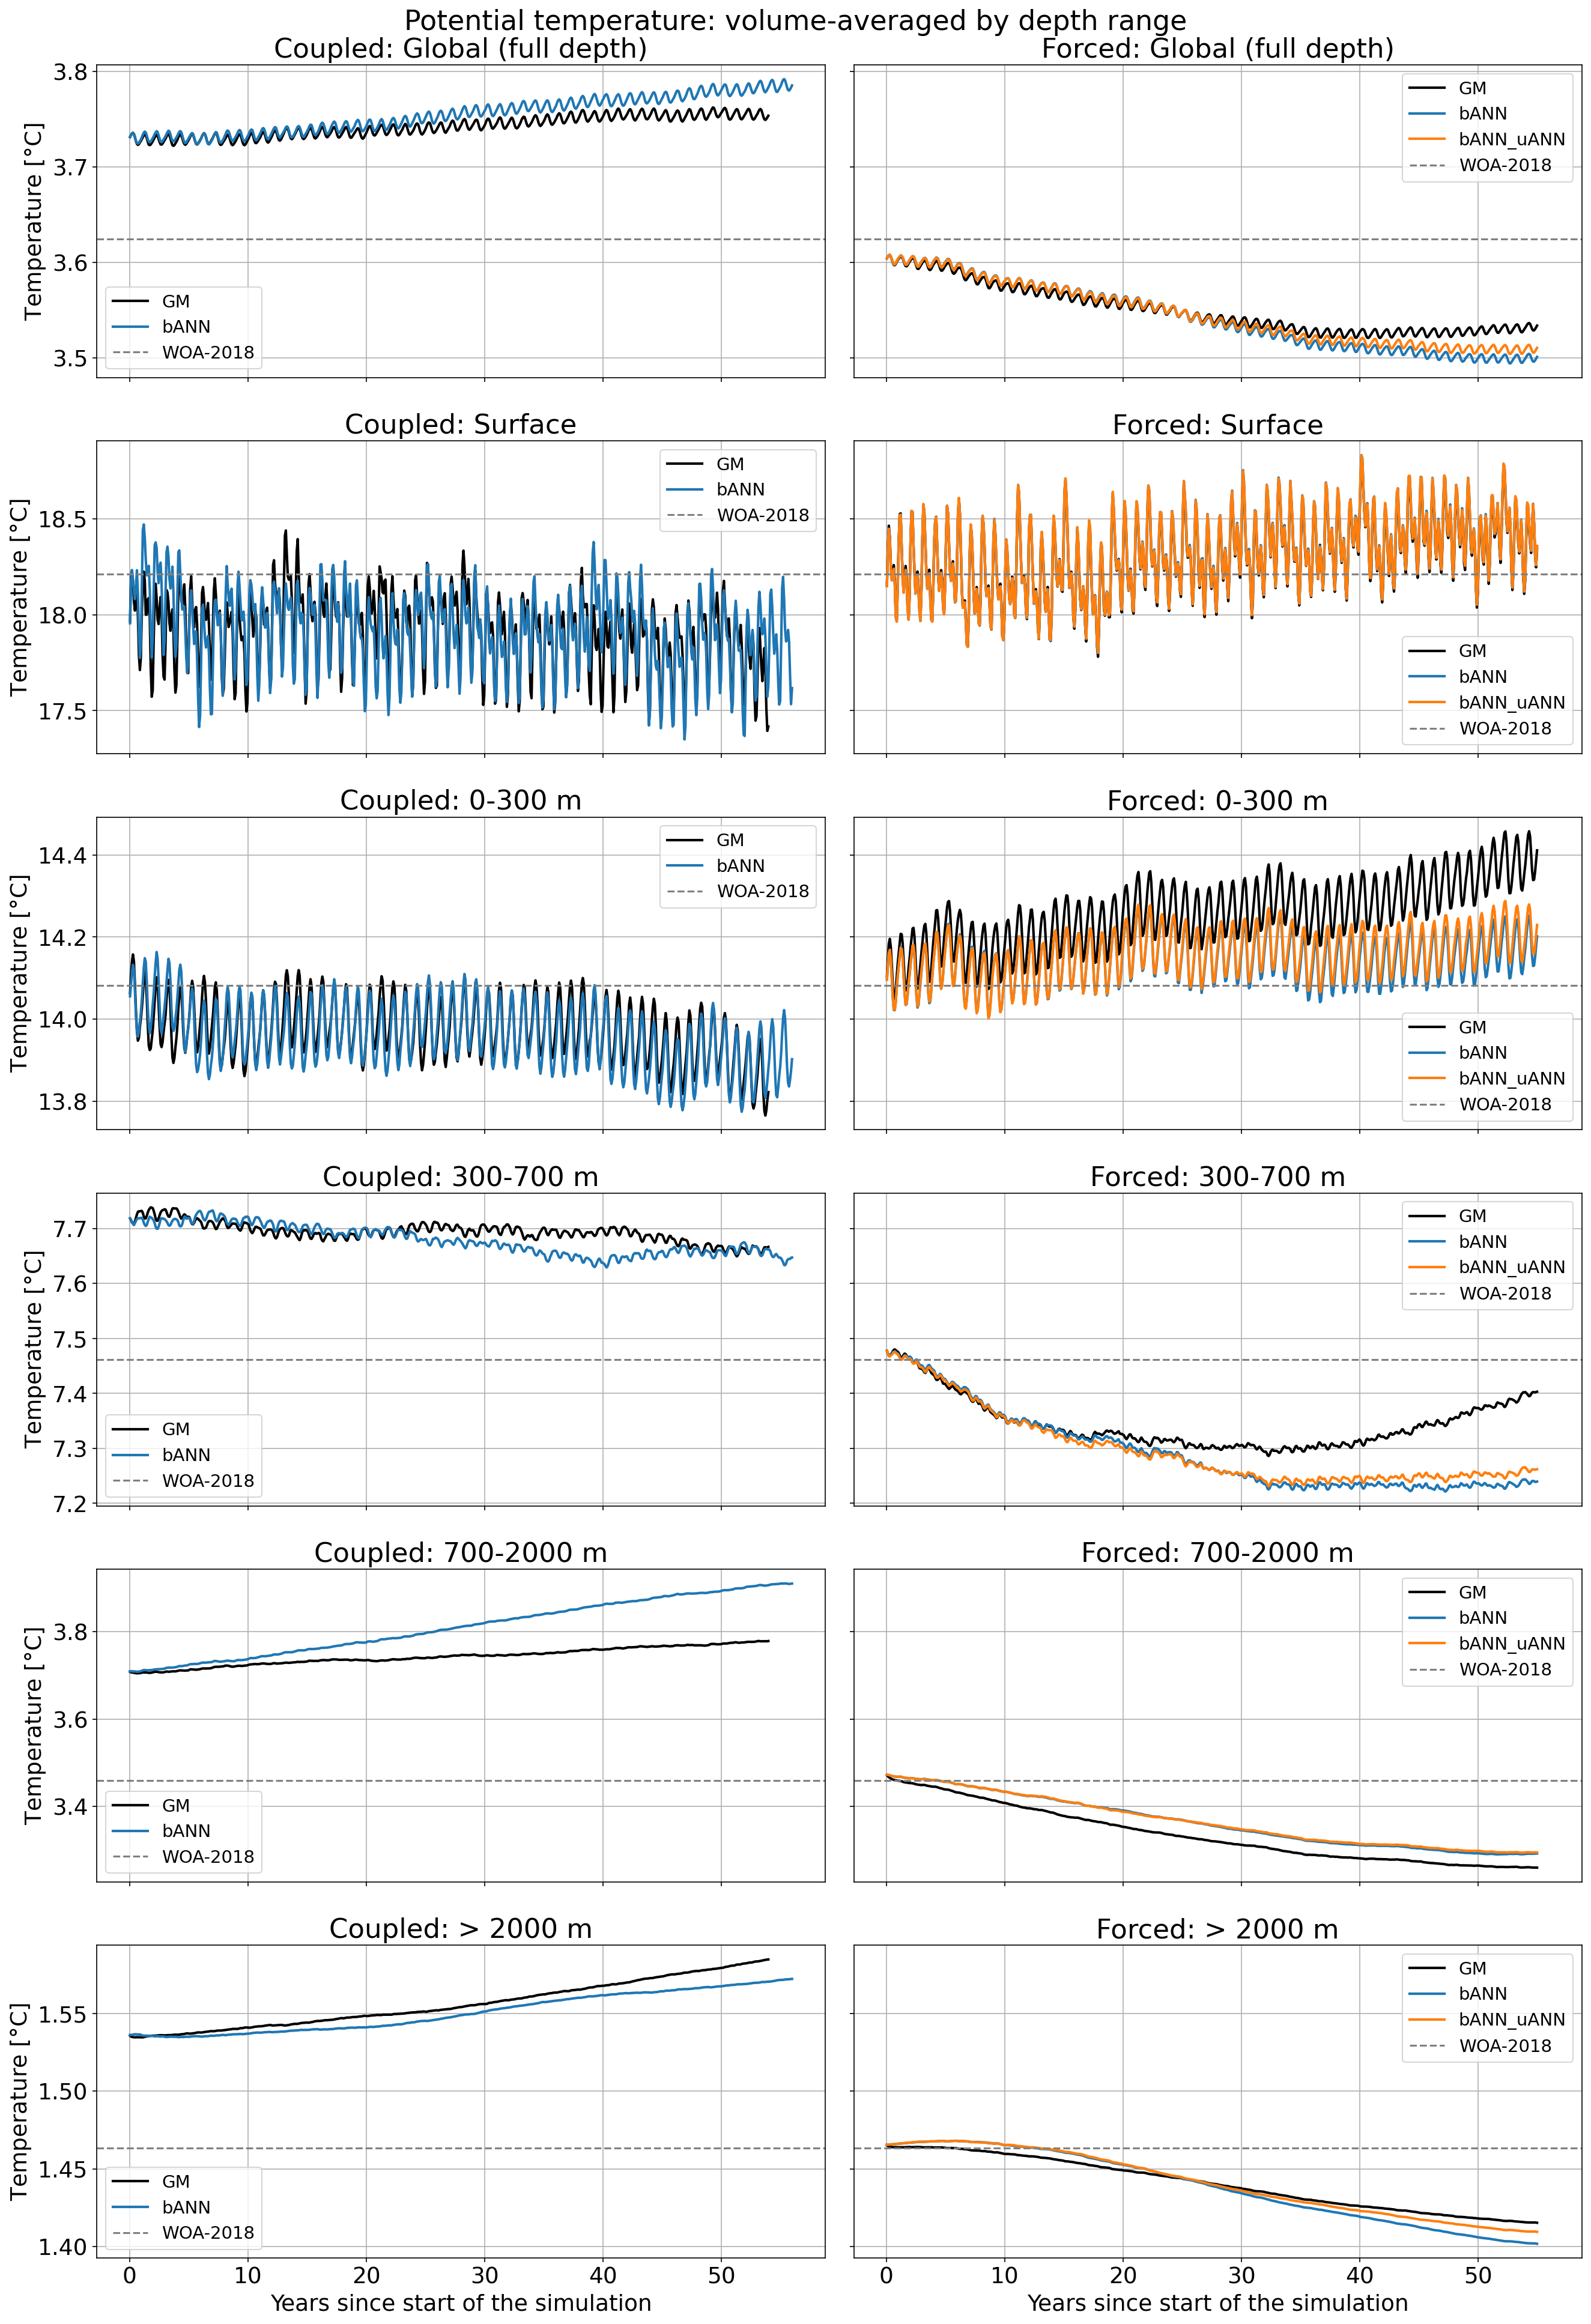

In [10]:
# Shared depth-range bookkeeping (labels, titles, and the WOA-2018
# reference for each range -- computed once here, reused by every panel).
# 'global' (full-depth volume mean, analogous to thetaoga/soga) is prepended
# and is not part of Experiment.OCEAN_HEAT_CONTENT_DEPTH_RANGES: it is
# derived on the fly from the cached (time, z_l) profiles rather than being
# its own cached variable.
DEPTH_RANGES = [('global', None, None), ('surface', None, None)] + Experiment.OCEAN_HEAT_CONTENT_DEPTH_RANGES
DEPTH_TITLES = {
    'global': 'Global (full depth)',
    'surface': 'Surface',
    '0_300m': '0-300 m',
    '300_700m': '300-700 m',
    '700_2000m': '700-2000 m',
    '2000m_plus': '> 2000 m',
}


def global_mean_timeseries(exp, var):
    # Full-depth volume-mean timeseries, derived from the cached (time,
    # z_l) profiles -- no re-reading of the raw history.
    ds = exp.ocean_heat_content()
    tprof = ds[f'{var}_volcello_profile']
    vprof = ds['volcello_profile']
    return tprof.sum('z_l') / vprof.sum('z_l')


def woa_reference(exp, var, label, lo, hi):
    # Volume- (or area-, for surface) weighted WOA-2018 reference for one
    # depth range, recovered as model - bias from the cached
    # *_thetao_time_mean.nc / *_so_time_mean.nc file. Uses the nominal layer
    # thickness reconstructed from the z_l midpoints, since a static
    # climatology has no per-cell layer-thickness diagnostic h.
    ds = exp.thetao() if var == 'thetao' else exp.so()
    obs = ds[var] - ds[f'{var}_bias']
    area = exp.area
    if label == 'surface':
        surf = obs.isel(z_l=0)
        return float((surf * area).sum() / area.where(surf.notnull()).sum())
    dz = layer_thickness_from_midpoints(obs['z_l'])
    if label == 'global':
        weight = (dz * area).where(obs.notnull())
        return float((obs * weight).sum() / weight.sum())
    if lo is None:
        zmask = obs['z_l'] <= hi
    elif hi is None:
        zmask = obs['z_l'] > lo
    else:
        zmask = (obs['z_l'] > lo) & (obs['z_l'] <= hi)
    z_sel = obs['z_l'].where(zmask, drop=True)
    obs_bin = obs.sel(z_l=z_sel)
    weight = (dz.sel(z_l=z_sel) * area).where(obs_bin.notnull())
    return float((obs_bin * weight).sum() / weight.sum())


def _set_year_ticks(ax, times):
    # Label the time axis as years since the start of the simulation (10-year ticks).
    y0 = times[0].year
    years = list(range(y0, times[-1].year + 2, 10))
    ax.set_xticks([cftime.DatetimeNoLeap(y, 1, 1) for y in years])
    ax.set_xticklabels([y - y0 for y in years])


def plot_depth_profile(var, long_name, unit):
    # 6x2 grid (rows = global + depth range, columns = Coupled/Forced) of
    # the volume-averaged timeseries, each panel overlaid with the
    # WOA-2018 reference for that row.
    nrows = len(DEPTH_RANGES)
    fig, axes = plt.subplots(nrows, 2, figsize=(18, 4.4 * nrows), dpi=150,
                             sharex=True, sharey='row')
    for row, (label, lo, hi) in enumerate(DEPTH_RANGES):
        woa_val = woa_reference(exps['CTRL'], var, label, lo, hi)
        for col, (regime, names) in enumerate([('Coupled', coupled_names),
                                               ('Forced', forced_names)]):
            ax = axes[row, col]
            ts = None
            for name in names:
                try:
                    if label == 'global':
                        da = global_mean_timeseries(exps[name], var)
                    else:
                        da = exps[name].ocean_heat_content()[f'{var}_{label}']
                except (FileNotFoundError, OSError, KeyError):
                    continue
                ts = da
                is_ctrl = name.endswith('CTRL')
                ts.plot(ax=ax, label=LABELS[name], lw=2,
                       color='k' if is_ctrl else None)
            ax.axhline(woa_val, color='gray', ls='--', lw=1.5,
                      label='WOA-2018')
            if ts is None:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=12)
            else:
                _set_year_ticks(ax, ts.time.values)
            ax.set_title(f'{regime}: {DEPTH_TITLES[label]}')
            ax.set_xlabel('')
            ax.set_ylabel(unit if col == 0 else '')
            ax.grid(True)
            ax.legend(loc='best', fontsize=14)
    axes[-1, 0].set_xlabel('Years since start of the simulation')
    axes[-1, 1].set_xlabel('Years since start of the simulation')
    fig.suptitle(f'{long_name}: volume-averaged by depth range', fontsize=22)
    plt.tight_layout()
    plt.show()


plot_depth_profile('thetao', 'Potential temperature', r'Temperature [$\degree$C]')


In [9]:
# plot_depth_profile('so', 'Salinity', 'Salinity [psu]')
